# Prototype build unique ds

Involved ds
- copernicus 1
- copernicus 2
- gfw ais
- gfw sar

Target ds columns
- date 
- latitude
- longitude
- chl
- thetao
- number of ais vessels
- number of ais gear 1
- number of ais gear 2
- ...
- number of sar vessels 

Filter: 
- optional filter to remove the Svn data


In [5]:
import pandas as pd
import os 
import numpy as np

# Set

In [6]:
year = 2024

input_path = "data/interim"
    # cmems_mod_med_phy-tem_anfc_4.2km_P1D-m
    # cmems_mod_med_bgc-pft_anfc_4.2km_P1D-m
cpr_product_name_1 = 'cmems_mod_med_bgc-pft_anfc_4.2km_P1D-m'
cpr_product_name_2 = 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m'
gfw_ais_product_name = 'ais_high_daily_ts'
gfw_sar_product_name = 's2_vessel_detections'

REMOVE_SVN_VESSELS = False

keys = ['date', 'latitude', 'longitude']
spatial_keys = ['latitude', 'longitude']
cpr_marine_var_1 = 'chl'
cpr_marine_var_2 = 'thetao'

# Automatic 

cpr_df_name_1 = f"cleaned_{cpr_product_name_1}_{year}.parquet"
cpr_df_name_2 = f"cleaned_{cpr_product_name_2}_{year}.parquet"
gfw_ais_df_name = f"cleaned_{gfw_ais_product_name}_{year}.parquet"
gfw_sar_df_name = f"cleaned_{gfw_sar_product_name}_{year}.parquet"

cpr_1_input = os.path.join(input_path, cpr_df_name_1)
cpr_2_input = os.path.join(input_path, cpr_df_name_2)
gfw_ais_input = os.path.join(input_path, gfw_ais_df_name)
gfw_sar_input = os.path.join(input_path, gfw_sar_df_name)

# Import 

In [7]:
cpr_1 = pd.read_parquet(cpr_1_input)
cpr_2 = pd.read_parquet(cpr_2_input)
gfw_ais = pd.read_parquet(gfw_ais_input)
gfw_sar = pd.read_parquet(gfw_sar_input)

In [8]:
gfw_sar.head()

,date,latitude,longitude,ssvid,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score
0,2024-05-09,45.558617,13.323862,294278974,0.84,177.043959,23.3,0.815
1,2024-06-26,45.756021,13.548380,247030610,0.35,359.335790,24.8,0.725
2,2024-05-17,45.651996,13.338790,243042758,2.31,113.445643,22.1,0.796
3,2024-05-17,45.655650,13.512470,None,0.58,71.619724,17.8,0.653
4,2024-05-17,45.748865,13.220594,247194770,7.60,93.392121,20.3,0.541


# Svn check


In [9]:
import matplotlib.pyplot as plt
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')
sar_unq_coords = gfw_sar.drop_duplicates(subset=['latitude', 'longitude']).copy()
ais_unq_coords = gfw_ais.drop_duplicates(subset=['latitude', 'longitude']).copy()
cpr_1_unq_coords = cpr_1.drop_duplicates(subset=['latitude', 'longitude']).copy()

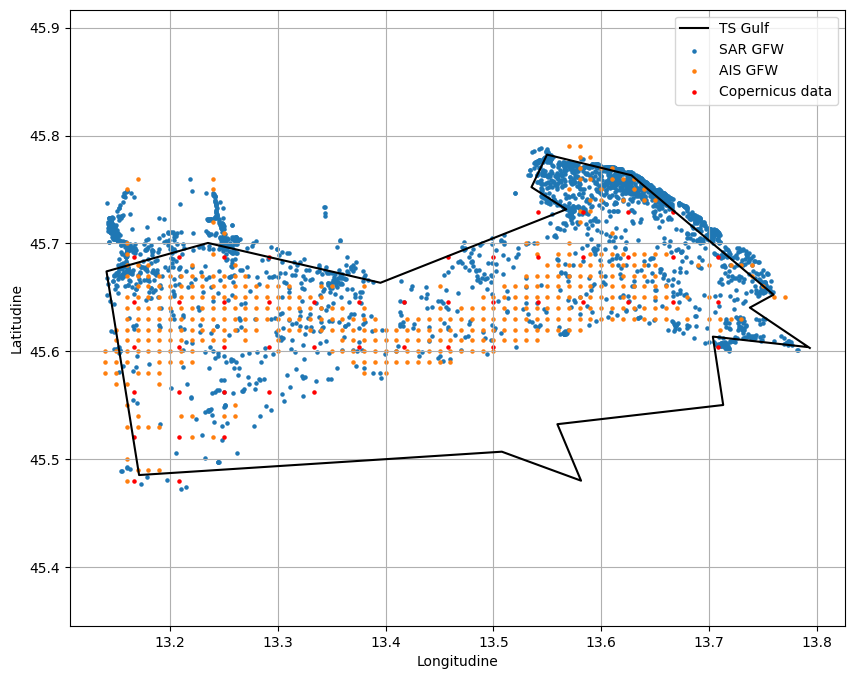

In [10]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(sar_unq_coords['longitude'], sar_unq_coords['latitude'], label = 'SAR GFW', s = 5)
plt.scatter(ais_unq_coords['longitude'], ais_unq_coords['latitude'], label = 'AIS GFW', s = 5)
plt.scatter(cpr_1_unq_coords['longitude'], cpr_1_unq_coords['latitude'], label = 'Copernicus data', color = 'red', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

# Filter duplicates in AIS-SAR

In [11]:
mmsi_set = set(gfw_ais["mmsi"].dropna().astype(str))
ssvid_set = set(gfw_sar["ssvid"].dropna().astype(str))

intersection = mmsi_set.intersection(ssvid_set)

print("Valori che coincidono tra codici AIS dei due dataset:", len(intersection))

Valori che coincidono tra codici AIS dei due dataset: 8


In [12]:
# crea insiemi di tuple (id, date)
ais_pairs = set(zip(gfw_ais["mmsi"], gfw_ais["date"]))
sar_pairs = set(zip(gfw_sar["ssvid"], gfw_sar["date"]))

# intersezione dei due insiemi
intersection = ais_pairs & sar_pairs

print("Numero di match ID+date:", len(intersection))
print("Esempi:", list(intersection)[:10])


Numero di match ID+date: 0
Esempi: []


In [13]:
# ID in comune
common_ids = set(gfw_ais["mmsi"]) & set(gfw_sar["ssvid"])

matches = []

for cid in common_ids:
    ais_dates = set(gfw_ais.loc[gfw_ais["mmsi"] == cid, "date"])
    sar_dates = set(gfw_sar.loc[gfw_sar["ssvid"] == cid, "date"])
    common_dates = ais_dates & sar_dates
    if common_dates:
        matches.append((cid, sorted(common_dates)))

print("Numero ID con almeno una data in comune:", len(matches))
print("Dettagli:", matches[:10])


Numero ID con almeno una data in comune: 0
Dettagli: []


In [14]:
gfw_sar_keys = gfw_sar[['date', 'ssvid']].drop_duplicates()
gfw_ais_keys = gfw_ais[['date', 'mmsi']].drop_duplicates()

merged = gfw_sar_keys.merge(
    gfw_ais_keys,
    left_on=['date', 'ssvid'],
    right_on=['date', 'mmsi'],
    how='inner')

merged.head()

if len(merged) == 0:
    print("Nessuna corrispondenza trovata tra i due dataset.")
else:
    raise ValueError("Sono stati trovati valori corrispondenti tra i due dataset!")

Nessuna corrispondenza trovata tra i due dataset.


# Build dataset

### Structure the df

In [15]:
df = cpr_1.drop_duplicates(subset=keys)[keys].copy()

In [16]:
print(df.shape[0])
df.head()

17934


,date,latitude,longitude
0,2024-01-01,45.479168,13.166667
1,2024-01-02,45.479168,13.166667
2,2024-01-03,45.479168,13.166667
3,2024-01-04,45.479168,13.166667
4,2024-01-05,45.479168,13.166667


### Enrich df with coperncius data 

In [17]:
df = pd.merge(
    left = df,
    right = cpr_1,
    how = 'left',
    on = keys
)

In [18]:
cols_to_save = keys + [cpr_marine_var_1] 
cols_to_drop = [col for col in df.columns if col not in cols_to_save]
df = df.drop(columns=cols_to_drop)

In [19]:
print(len(df))
df.head()

17934


,date,latitude,longitude,chl
0,2024-01-01,45.479168,13.166667,0.432612
1,2024-01-02,45.479168,13.166667,0.409951
2,2024-01-03,45.479168,13.166667,0.387921
3,2024-01-04,45.479168,13.166667,0.367288
4,2024-01-05,45.479168,13.166667,0.347252


In [20]:
df = pd.merge(
    left = df,
    right = cpr_2,
    how = 'left',
    on = keys
)

In [21]:
cols_to_save = keys + [cpr_marine_var_1, cpr_marine_var_2] 
cols_to_drop = [col for col in df.columns if col not in cols_to_save]
df = df.drop(columns=cols_to_drop)

In [22]:
print(len(df))
df.head()

17934


,date,latitude,longitude,chl,thetao
0,2024-01-01,45.479168,13.166667,0.432612,13.304394
1,2024-01-02,45.479168,13.166667,0.409951,13.248711
2,2024-01-03,45.479168,13.166667,0.387921,13.063446
3,2024-01-04,45.479168,13.166667,0.367288,12.772483
4,2024-01-05,45.479168,13.166667,0.347252,13.004619


### Enrich sar with target_lat, target_lon

In [23]:
sar_len_before = len(gfw_sar)

In [24]:
sar_unq_coords = gfw_sar.drop_duplicates(subset=spatial_keys)[spatial_keys].copy()

In [25]:
df_unq_coords = df.drop_duplicates(subset=spatial_keys)[spatial_keys].copy()

In [26]:
def project_to_nearest(
    coords_to_project: pd.DataFrame,
    coords_target: pd.DataFrame,
    lat_col: str = "latitude",
    lon_col: str = "longitude",
    return_distance: bool = True,
):
    """
    For each (lat, lon) in coords_to_project, find the nearest (lat, lon) in coords_target
    using great-circle (haversine) distance.

    Returns a DataFrame with:
      - lat, lon (from coords_to_project)
      - lat_nearest, lon_nearest (nearest coords from coords_target)
      - distance_m (optional; great-circle distance in meters)

    Notes:
      - Expects lat/lon in degrees.
      - Requires scikit-learn (BallTree). If not available, falls back to a slower NumPy version.
    """
    # Select and sanity-check inputs
    A = coords_to_project[[lat_col, lon_col]].to_numpy().astype(float)
    B = coords_target[[lat_col, lon_col]].to_numpy().astype(float)

    if A.size == 0 or B.size == 0:
        raise ValueError("Empty inputs: both coords_to_project and coords_target must have rows.")

    # Try fast haversine search via BallTree
    try:
        from sklearn.neighbors import BallTree

        # BallTree with haversine expects radians; distances are returned in radians
        A_rad = np.radians(A)
        B_rad = np.radians(B)
        tree = BallTree(B_rad, metric="haversine")
        dist_rad, ind = tree.query(A_rad, k=1)  # shape: (n, 1)

        # Convert outputs
        nearest = B[ind[:, 0]]  # back in degrees
        if return_distance:
            earth_radius_m = 6371000.0
            dist_m = (dist_rad[:, 0] * earth_radius_m)
        else:
            dist_m = None

    except Exception:
        # Fallback: vectorized NumPy (euclidean on degrees ≈ OK for tiny areas)
        # If your domain is larger, consider installing scikit-learn.
        A_exp = np.radians(A)[:, None, :]      # (n,1,2)
        B_exp = np.radians(B)[None, :, :]      # (1,m,2)

        # Haversine distance (vectorized)
        dlat = B_exp[..., 0] - A_exp[..., 0]
        dlon = B_exp[..., 1] - A_exp[..., 1]
        a = np.sin(dlat/2)**2 + np.cos(A_exp[..., 0]) * np.cos(B_exp[..., 0]) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        earth_radius_m = 6371000.0
        D = earth_radius_m * c  # (n, m)

        ind = np.argmin(D, axis=1)
        nearest = B[ind]
        dist_m = D[np.arange(D.shape[0]), ind] if return_distance else None

    # Build result table
    out = pd.DataFrame({
        lat_col: A[:, 0],
        lon_col: A[:, 1],
        "lat_nearest": nearest[:, 0],
        "lon_nearest": nearest[:, 1],
    })
    if return_distance:
        out["distance_m"] = dist_m

    return out


In [27]:
coords_prj_table = project_to_nearest(
    coords_to_project = sar_unq_coords,
    coords_target = df_unq_coords,
    lat_col="latitude",
    lon_col="longitude"
)

coords_prj_table = coords_prj_table.drop(columns = ['distance_m'])

In [28]:
print(len(sar_unq_coords))
print(len(df_unq_coords))
print(len(coords_prj_table))

2597
49
2597


In [29]:
gfw_sar = pd.merge(
    left = gfw_sar,
    right = coords_prj_table,
    how = 'left',
    on = spatial_keys
)

In [30]:
gfw_sar = gfw_sar.drop(columns=spatial_keys)
gfw_sar = gfw_sar.rename(columns={
    'lat_nearest': 'latitude',
    'lon_nearest': 'longitude'
})

In [31]:
print('sar len before merge:', sar_len_before)
print('sar len after merge:', len(gfw_sar))
gfw_sar.head()

sar len before merge: 2604
sar len after merge: 2604


,date,ssvid,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,latitude,longitude
0,2024-05-09,294278974,0.84,177.043959,23.3,0.815,45.562500,13.333333
1,2024-06-26,247030610,0.35,359.335790,24.8,0.725,45.729168,13.541667
2,2024-05-17,243042758,2.31,113.445643,22.1,0.796,45.645832,13.333333
3,2024-05-17,None,0.58,71.619724,17.8,0.653,45.645832,13.500000
4,2024-05-17,247194770,7.60,93.392121,20.3,0.541,45.687500,13.208333


### Enrich df with sar data 

In [32]:
gfw_sar_grp = gfw_sar.groupby(keys).size().reset_index(name='sar_vessels_count')

In [33]:
gfw_sar_grp['date'] = gfw_sar_grp['date'].astype('datetime64[ns]') 

In [34]:
print(len(gfw_sar_grp))
print(len(df))
print('---')
df = pd.merge(
    left = df,
    right = gfw_sar_grp,
    how = 'left',
    on = keys
)
print(len(df))

885
17934
---
17934


In [35]:
df['sar_vessels_count'] = df['sar_vessels_count'].fillna(0)

In [36]:
df.head()

,date,latitude,longitude,chl,thetao,sar_vessels_count
0,2024-01-01,45.479168,13.166667,0.432612,13.304394,0.0
1,2024-01-02,45.479168,13.166667,0.409951,13.248711,0.0
2,2024-01-03,45.479168,13.166667,0.387921,13.063446,0.0
3,2024-01-04,45.479168,13.166667,0.367288,12.772483,0.0
4,2024-01-05,45.479168,13.166667,0.347252,13.004619,0.0


### Enrich ais with target_lat, target_lon

In [37]:
ais_len_before = len(gfw_ais)

In [38]:
ais_unq_coords = gfw_ais.drop_duplicates(subset=spatial_keys)[spatial_keys].copy()

In [39]:
df_unq_coords = df.drop_duplicates(subset=spatial_keys)[spatial_keys].copy()

In [40]:
coords_prj_table = project_to_nearest(
    coords_to_project = ais_unq_coords,
    coords_target = df_unq_coords,
    lat_col="latitude",
    lon_col="longitude"
)

coords_prj_table = coords_prj_table.drop(columns = ['distance_m'])

In [41]:
print(len(ais_unq_coords))
print(len(df_unq_coords))
print(len(coords_prj_table))

417
49
417


In [42]:
gfw_ais = pd.merge(
    left = gfw_ais,
    right = coords_prj_table,
    how = 'left',
    on = spatial_keys
)

In [43]:
gfw_ais = gfw_ais.drop(columns=spatial_keys)
gfw_ais = gfw_ais.rename(columns={
    'lat_nearest': 'latitude',
    'lon_nearest': 'longitude'
})

In [44]:
print('ais len before merge:', ais_len_before)
print('ais len after merge:', len(gfw_ais))
gfw_ais.head()

ais len before merge: 4035
ais len after merge: 4035


,date,gear_type,mmsi,ship_name,hours,flag,latitude,longitude
0,2024-07-24,TRAWLERS,247050940,RINA S.,1.014167,ITA,45.645832,13.333333
1,2024-12-11,TRAWLERS,247030160,USODIMARE,0.325556,ITA,45.604168,13.416667
2,2024-07-07,TRAWLERS,247050940,RINA S.,0.961667,ITA,45.687500,13.250000
3,2024-11-05,TRAWLERS,247030180,ALBATROS,1.007222,ITA,45.645832,13.208333
4,2024-05-15,TRAWLERS,247050940,RINA S.,0.981111,ITA,45.604168,13.375000


### Enrich df with ais data 

In [45]:
# total per (keys)
ais_totals = gfw_ais.groupby(keys).size().rename('ais_vessels_count')

# per-gear counts, including NaN as its own column
ais_gear_counts = (
    gfw_ais
    .groupby(keys + ['gear_type'], dropna=False)   # <-- keep NaNs
    .size()
    .unstack('gear_type', fill_value=0)
)

gfw_ais_grp = ais_totals.to_frame().join(ais_gear_counts).reset_index()


In [46]:
gfw_ais_grp.head(3)

,date,latitude,longitude,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-02,45.604168,13.416667,1,0,0,0,0,1
1,2024-01-02,45.604168,13.500000,2,0,0,0,0,2
2,2024-01-02,45.645832,13.541667,2,0,0,0,0,2


In [47]:
gfw_ais_grp['date'] = gfw_ais_grp['date'].astype('datetime64[ns]') 

In [48]:
print(len(gfw_ais_grp))
print(len(df))
print('---')
df = pd.merge(
    left = df,
    right = gfw_ais_grp,
    how = 'left',
    on = keys
)
print(len(df))

1662
17934
---
17934


In [49]:
df.head()

,date,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,45.479168,13.166667,0.432612,13.304394,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,45.479168,13.166667,0.409951,13.248711,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,45.479168,13.166667,0.387921,13.063446,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,45.479168,13.166667,0.367288,12.772483,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,45.479168,13.166667,0.347252,13.004619,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
for col in list(df.columns):
    df[col] = df[col].fillna(0)

In [51]:
df.head()

,date,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Holidays and weekend 

In [53]:
import pandas as pd
import holidays

# Assicuriamoci che la colonna date sia in formato datetime
df["date"] = pd.to_datetime(df["date"])

# Definisci i festivi italiani per il 2024
it_holidays_2024 = holidays.country_holidays("IT", years=year)

# Colonna booleana: True se è festivo nazionale, False altrimenti
df["is_holiday"] = df["date"].dt.date.isin(it_holidays_2024)

# (opzionale) Colonna col nome della festa, altrimenti None
df["holiday_name"] = df["date"].dt.date.map(lambda d: it_holidays_2024.get(d))


In [54]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5

# Fishing stop 

In [55]:
print("Inserted just for 2024")
if year == 2024:
    df['fishing_block'] = False
    # add fishing block = true if date in [31 luglio al 13 settembre]
    df.loc[
        (df['date'] >= pd.Timestamp(f'{year}-07-31')) & (df['date'] <= pd.Timestamp(f'{year}-09-13')),
        'fishing_block'
    ] = True

Inserted just for 2024


In [56]:
df[
    df['fishing_block'] == True
].head()

,date,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS,is_holiday,holiday_name,is_weekend,fishing_block
212,2024-07-31,45.479168,13.166667,0.145149,27.140240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,None,False,True
213,2024-08-01,45.479168,13.166667,0.133230,27.798201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,None,False,True
214,2024-08-02,45.479168,13.166667,0.119251,28.016808,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,None,False,True
215,2024-08-03,45.479168,13.166667,0.107215,27.786982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,None,True,True
216,2024-08-04,45.479168,13.166667,0.097096,27.462158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,None,True,True


# Re order columns

In [57]:
my_order = ['date',
 'is_holiday',
 'holiday_name',
 'is_weekend',
 'fishing_block',
 'latitude',
 'longitude',
 'chl',
 'thetao',
 'sar_vessels_count',
 'ais_vessels_count',
 'DREDGE_FISHING',
 'FISHING',
 'OTHER_PURSE_SEINES',
 'POTS_AND_TRAPS',
 'TRAWLERS',
 ]
df = df[my_order]

In [58]:
df.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,False,None,False,False,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,False,None,False,False,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,False,None,False,False,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,False,None,False,False,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Export 

In [59]:
out_path = "data/processed"
out_name = f"cpr_gfw_{year}.parquet"
out = os.path.join(out_path, out_name)

df.to_parquet(out, index=False)